In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

### Dataset

In [23]:
df = pd.read_csv("../data/raw_market/EURUSD_H1_20210501_20260331.csv", parse_dates=["time"])
df.set_index("time", inplace=True)
df.drop(columns=["spread", "real_volume"], inplace=True)

display(df.head())
display(df.describe())

,open,high,low,close,tick_volume
time,,,,,
2021-05-02 21:00:00+00:00,1.20308,1.20328,1.20084,1.20233,398
2021-05-02 22:00:00+00:00,1.20235,1.20285,1.20207,1.20269,441
2021-05-02 23:00:00+00:00,1.20272,1.20302,1.20248,1.20272,473
2021-05-03 00:00:00+00:00,1.20271,1.20337,1.20202,1.20337,1064
2021-05-03 01:00:00+00:00,1.20338,1.20354,1.20266,1.20276,914


,open,high,low,close,tick_volume
count,30587.000000,30587.000000,30587.000000,30587.000000,30587.000000
mean,1.102807,1.103518,1.102101,1.102812,2624.962893
std,0.054432,0.054339,0.054513,0.054430,1685.400925
min,0.953940,0.955940,0.953620,0.953900,1.000000
25%,1.068535,1.069250,1.067840,1.068535,1396.000000
50%,1.091760,1.092390,1.091110,1.091760,2293.000000
75%,1.154175,1.155050,1.153455,1.154200,3442.500000
max,1.225970,1.226640,1.225610,1.225970,16362.000000


### Time Gaps Analysis

In [24]:
expected_freq = "1h"

time_deltas = df.index.to_series().diff()
expected_delta = pd.to_timedelta(expected_freq)

anomalous_gaps = time_deltas[(time_deltas > expected_delta) & (time_deltas < pd.Timedelta(days=2))]

print(f"Number of anomalous gaps: {len(anomalous_gaps)}")
anomalous_gaps

Number of anomalous gaps: 5


time
2021-12-02 14:00:00+00:00   0 days 06:00:00
2024-12-25 22:00:00+00:00   1 days 01:00:00
2025-01-01 22:00:00+00:00   1 days 01:00:00
2025-12-25 22:00:00+00:00   1 days 01:00:00
2026-01-01 22:00:00+00:00   1 days 01:00:00
Name: time, dtype: timedelta64[us]

In [25]:
# Strip any existing dead hours recorded by the broker
df = df[df['tick_volume'] > 0]

# Forward-fill any internal NaNs just in case a price packet dropped but volume registered
df.ffill(inplace=True)

print(f"Zero volume rows: {len(df[df['tick_volume'] == 0])}")
print(f"Remaining NaNs: {df.isna().sum().sum()}")

Zero volume rows: 0
Remaining NaNs: 0


### Return Distribution

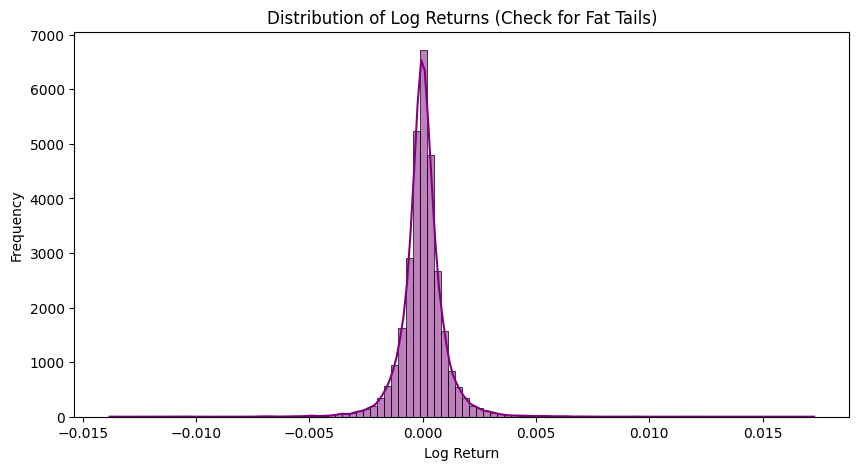

Skewness: 0.04 (0 is perfectly symmetrical)
Kurtosis: 16.18 (>3 indicates extreme outliers/fat tails)


In [26]:
prices_close = df["close"]
log_returns = (prices_close / prices_close.shift(1)).apply(np.log)
log_returns = log_returns.dropna()

plt.figure(figsize=(10, 5))
sns.histplot(x=log_returns, bins=100, kde=True, color='purple')
plt.title("Distribution of Log Returns (Check for Fat Tails)")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.show()

# Kurtosis > 3 means fat tails. High kurtosis will blow up your MSE/Cross-Entropy gradients.
print(f"Skewness: {log_returns.skew():.2f} (0 is perfectly symmetrical)")
print(f"Kurtosis: {log_returns.kurtosis():.2f} (>3 indicates extreme outliers/fat tails)")

Because the Kurtosis is too high, its best to use RobustScaler

### Profile Tick Volume

C:\Users\kavin\AppData\Local\Temp\ipykernel_23796\1916390112.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_volume.index, y=hourly_volume.values, palette='Blues_d')


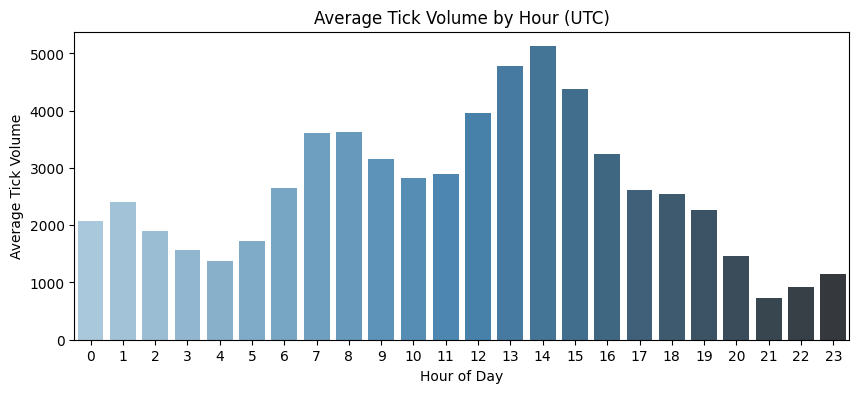

In [27]:
hourly_volume = df.groupby(df.index.hour)['tick_volume'].mean() # type: ignore

plt.figure(figsize=(10, 4))
sns.barplot(x=hourly_volume.index, y=hourly_volume.values, palette='Blues_d')
plt.title("Average Tick Volume by Hour (UTC)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Tick Volume")
plt.show()

### Chart Visualization

In [28]:
plot_df = df.loc["2026-01-01":"2026-01-31"]

time_step = pd.Timedelta(plot_df.index.to_series().diff().median())
dynamic_dvalue = int(time_step.total_seconds() * 1000)

fig = go.Figure(data=[go.Candlestick(x=plot_df.index,
                open=plot_df["open"],
                high=plot_df["high"],
                low=plot_df["low"],
                close=plot_df["close"],
                name="Market Data")]
                )

fig.update_layout(
    title="EUR/USD Price Action",
    yaxis_title="Price",
    xaxis_title="Time",
    template="plotly_dark",
    xaxis_rangeslider_visible=False,
    height=600
)

# identify missing timestamps in the hourly data
full_timeline = pd.date_range(start=plot_df.index.min(), end=plot_df.index.max(), freq=time_step)
missing_timestamps = full_timeline.difference(pd.DatetimeIndex(plot_df.index))

# hide missing timestamps on the x-axis to avoid gaps in the candlestick chart
fig.update_xaxes(
    rangebreaks=[
        dict(values=missing_timestamps, dvalue=dynamic_dvalue)
    ]
)

fig.show()

In [30]:
total_rows = len(df)
first_timestamp = df.index[0]
last_timestamp = df.index[-1]
nans_in_close = df['close'].isna().sum()

print(f"Total Rows: {total_rows}")
print(f"First Timestamp: {first_timestamp}")
print(f"Last Timestamp: {last_timestamp}")
print(f"Number of NaNs in Close: {nans_in_close}")

Total Rows: 30587
First Timestamp: 2021-05-02 21:00:00+00:00
Last Timestamp: 2026-03-31 20:00:00+00:00
Number of NaNs in Close: 0
